### 기본 라이브러리

In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import make_scorer

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix, classification_report


In [66]:
def resumetable(df):
  print(f'데이터셋 크기: {df.shape}')                                # 데이터프레임의 전체 크기(행, 열) 출력

  summary = pd.DataFrame(df.dtypes, columns=['데이터 타입'])         # 각 피처의 데이터 타입을 가져와 데이터프레임으로 생성
  summary = summary.reset_index()                                    # 인덱스를 초기화하여 컬럼으로 변환
  summary = summary.rename(columns={'index':'피처'})                 # 'index' 컬럼명을 '피처'로 변경

  summary['결측값 개수'] = df.isnull().sum().values                 # 각 피처의 결측값(null) 개수 계산
  summary['고유값 개수'] = df.nunique().values                      # 각 피처의 고유값 개수 계산

  summary['첫 번째 값'] = df.loc[0].values                          # 각 피처의 첫 번째 샘플 값
  summary['두 번째 값'] = df.loc[1].values                          # 각 피처의 두 번째 샘플 값
  summary['세 번째 값'] = df.loc[2].values                          # 각 피처의 세 번째 샘플 값

  return summary                                                     # 요약 테이블 반환

### [1단계] 이진 분류

1. E vs E가 아닌 것

In [2]:
# 데이터 불러오기
df = pd.read_csv("./result/상위20개컬럼.csv")

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Data columns (total 21 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   이용금액_R3M_신용체크    int64 
 1   _2순위카드이용금액       int64 
 2   _1순위업종_이용금액      int64 
 3   정상입금원금_B5M       int64 
 4   이용금액_오프라인_B0M    int64 
 5   _2순위업종_이용금액      int64 
 6   최대이용금액_일시불_R12M  int64 
 7   연체입금원금_B0M       int64 
 8   _3순위쇼핑업종_이용금액    int64 
 9   이용건수_오프라인_R6M    int64 
 10  정상입금원금_B2M       int64 
 11  _3순위업종_이용금액      int64 
 12  _1순위교통업종_이용금액    int64 
 13  이용건수_신용_R12M     int64 
 14  쇼핑_도소매_이용금액      int64 
 15  이용금액_오프라인_R6M    int64 
 16  청구금액_B0          int64 
 17  청구금액_R6M         int64 
 18  평잔_일시불_3M        int64 
 19  잔액_일시불_B0M       int64 
 20  Segment          object
dtypes: int64(20), object(1)
memory usage: 384.5+ MB
None


In [67]:
resumetable(df)

데이터셋 크기: (2400000, 21)


,피처,데이터 타입,결측값 개수,고유값 개수,첫 번째 값,두 번째 값,세 번째 값
0,이용금액_R3M_신용체크,int64,0,124193,196,13475,23988
1,_2순위카드이용금액,int64,0,53948,0,0,0
2,_1순위업종_이용금액,int64,0,59635,1928,2158,16924
3,정상입금원금_B5M,int64,0,43485,9205,2546,16949
4,이용금액_오프라인_B0M,int64,0,16595,4043,3980,4524
5,_2순위업종_이용금액,int64,0,22337,1408,2083,1539
6,최대이용금액_일시불_R12M,int64,0,83560,4906,10407,10112
7,연체입금원금_B0M,int64,0,21486,8104,826,9364
8,_3순위쇼핑업종_이용금액,int64,0,3949,0,315,924
9,이용건수_오프라인_R6M,int64,0,1054,54,95,76


In [41]:
# 이진 타겟 생성
df["is_E"] = (df["Segment"] == "E").astype(int)

# 입력 변수와 타겟 분리
X = df.drop(columns=["Segment", "is_E"])
y = df["is_E"]

# 입력 데이터 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 훈련/검증 나누기
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

In [42]:
# 모델 정의 및 학습
model_bin = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    tree_method="hist", 
    device="cuda"
)
model_bin.fit(X_train, y_train)

# 예측 및 결과 확인
y_pred = model_bin.predict(X_val)
print("[1단계] E vs Not E 이진 분류 결과")
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

[1단계] E vs Not E 이진 분류 결과
[[ 65969  29621]
 [ 19184 365226]]
              precision    recall  f1-score   support

           0       0.77      0.69      0.73     95590
           1       0.92      0.95      0.94    384410

    accuracy                           0.90    480000
   macro avg       0.85      0.82      0.83    480000
weighted avg       0.90      0.90      0.90    480000



#### 1단계 결과 해석
| 항목                   | 해석                                              |
| -------------------- | ----------------------------------------------- |
| **Accuracy: 90%**    | 전체 예측 정확도 우수                                    |
| **Class 1 (E)**      | Precision 0.92 / Recall 0.95 → **잘 예측됨**        |
| **Class 0 (비E)**     | Recall 0.69 → **E 아닌 걸 놓치는 경우 있음**, 하지만 큰 문제 아님 |
| **Macro avg = 0.83** | 클래스 간 균형도 준수                                    |  

- 요약: E 클래스는 잘 잡아내고 있고, 이제 비E 데이터만 추출해서 A/B/C/D 분류로 넘어간다.


### [2단계] Not E 데이터만 추출 -> A/B/C/d 분류

In [43]:
# 1. 비E 데이터만 추출
df_not_e = df[df['Segment'] != 'E'].copy()

# 2. 입력 변수, 타겟 재정의
X_not_e = df_not_e.drop(columns=['Segment', 'is_E'])
y_not_e = df_not_e['Segment']

# 3. 타겟 인코딩
le_abcd = LabelEncoder()
y_not_e_encoded = le_abcd.fit_transform(y_not_e)

# 4. 학습/검증 나누기
X_train_ne, X_val_ne, y_train_ne, y_val_ne = train_test_split(
    X_not_e, y_not_e_encoded, test_size=0.2, stratify=y_not_e_encoded, random_state=42
)

In [44]:
# 5. XGBoost 다중분류 모델 정의 및 학습
model_abcd = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    tree_method="hist",
    device="cuda"
)

model_abcd.fit(X_train_ne, y_train_ne)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=4, ...)

In [45]:
# 6. 결과 확인
y_pred_ne = model_abcd.predict(X_val_ne)
print("[2단계] Not E 데이터 A/B/C/D 분류 결과")
print(classification_report(y_val_ne, y_pred_ne, target_names=le_abcd.classes_))

[2단계] Not E 데이터 A/B/C/D 분류 결과
              precision    recall  f1-score   support

           A       0.74      0.19      0.30       194
           B       1.00      0.03      0.07        29
           C       0.73      0.52      0.61     25518
           D       0.84      0.93      0.88     69849

    accuracy                           0.82     95590
   macro avg       0.83      0.42      0.47     95590
weighted avg       0.81      0.82      0.81     95590



#### 2단계 결과 해석
| 클래스   | Precision | Recall | F1-score | 샘플 수   | 해석                        |
| ----- | --------- | ------ | -------- | ------ | ------------------------- |
| **A** | 0.74      | 0.19   | 0.30     | 194    | 거의 다 놓침 (Recall 낮음)       |
| **B** | 1.00      | 0.03   | 0.07     | 29     | 너무 적게 잡음 (고정도지만 감지 거의 안됨) |
| **C** | 0.73      | 0.52   | 0.61     | 25,518 | 괜찮음                       |
| **D** | 0.84      | 0.93   | 0.88     | 69,849 | 매우 우수                     |

#### 주성분 검사 

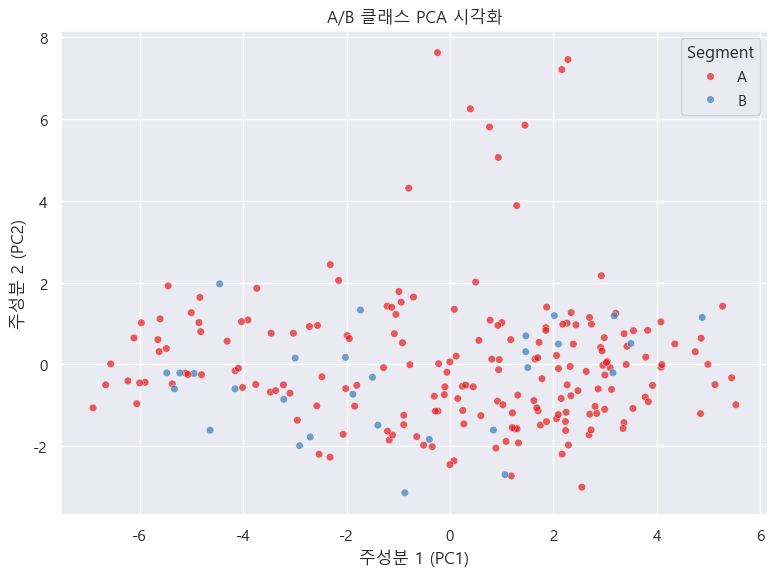

In [61]:
from sklearn.decomposition import PCA

# A/B 클래스만 추출
mask_ab = (y_val_ne == le_abcd.transform(['A'])[0]) | (y_val_ne == le_abcd.transform(['B'])[0])
X_ab = X_val_ne[mask_ab]
y_ab = y_val_ne[mask_ab]

# 스케일링
scaler = StandardScaler()
X_ab_scaled = scaler.fit_transform(X_ab)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_ab_scaled)

# 시각화용 DataFrame 생성
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Segment'] = le_abcd.inverse_transform(y_ab)

# 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Segment', palette='Set1', s=30, alpha=0.7)
plt.title("A/B 클래스 PCA 시각화")
plt.xlabel("주성분 1 (PC1)")
plt.ylabel("주성분 2 (PC2)")
plt.legend(title='Segment')
plt.grid(True)
plt.tight_layout()
plt.show()

| 관찰 내용                          | 해석                                         |
| ------------------------------ | ------------------------------------------ |
| 🔴 A 클래스는 넓게 퍼져 있고 위쪽까지 분포함    | A 클래스는 **다양한 패턴**을 가질 수 있음                 |
| 🔵 B 클래스는 대부분 X축 중심선 근처에 뭉쳐 있음 | B 클래스는 **패턴이 제한적**이고 **분산이 작음**            |
| A와 B의 영역이 **명확히 분리되어 있지 않음**   | 두 클래스 간의 **경계가 불분명**하여 분류가 어렵다         |
| 일부 🔴 점이 🔵 사이에 존재함            | A 클래스 일부가 B와 비슷한 특성을 가짐 → **모델이 혼동할 수 있음** |

In [62]:
# 이미 학습된 PCA 객체 기준
# pca는 앞서 사용한 PCA(n_components=2) 객체라고 가정
# X_ab_scaled는 PCA에 사용된 스케일링된 입력 데이터
# X_ab.columns는 원래 피처 이름

# 주성분 구성 DataFrame 만들기
components_df = pd.DataFrame(
    data=pca.components_,
    columns=X_ab.columns,
    index=['PC1', 'PC2']
).T  # 전치해서 피처별로 보기 쉽게

# 절댓값 기준 기여도 순 정렬해서 상위 피처 보기
top_pc1 = components_df['PC1'].abs().sort_values(ascending=False).head(10)
top_pc2 = components_df['PC2'].abs().sort_values(ascending=False).head(10)

print("[PC1에 가장 큰 영향을 미친 피처 Top 10]")
print(top_pc1)

print("\n[PC2에 가장 큰 영향을 미친 피처 Top 10]")
print(top_pc2)


[PC1에 가장 큰 영향을 미친 피처 Top 10]
이용금액_R3M_신용체크    0.297619
_2순위업종_이용금액      0.280668
이용건수_신용_R12M     0.275875
_3순위쇼핑업종_이용금액    0.266899
이용건수_오프라인_R6M    0.262028
_3순위업종_이용금액      0.258512
쇼핑_도소매_이용금액      0.253901
이용금액_오프라인_R6M    0.234310
잔액_일시불_B0M       0.231836
평잔_일시불_3M        0.227878
Name: PC1, dtype: float64

[PC2에 가장 큰 영향을 미친 피처 Top 10]
청구금액_B0            0.488283
청구금액_R6M           0.459535
정상입금원금_B2M         0.407564
정상입금원금_B5M         0.399008
최대이용금액_일시불_R12M    0.236706
연체입금원금_B0M         0.215962
평잔_일시불_3M          0.182999
잔액_일시불_B0M         0.166590
_2순위카드이용금액         0.126486
이용금액_R3M_신용체크      0.091289
Name: PC2, dtype: float64


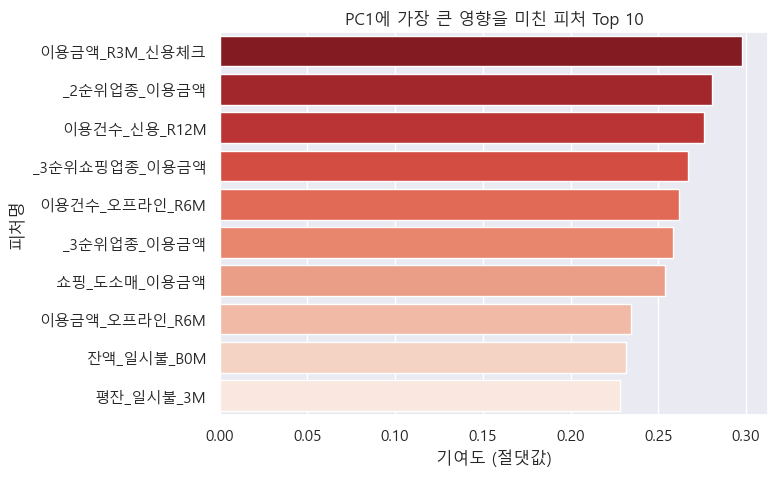

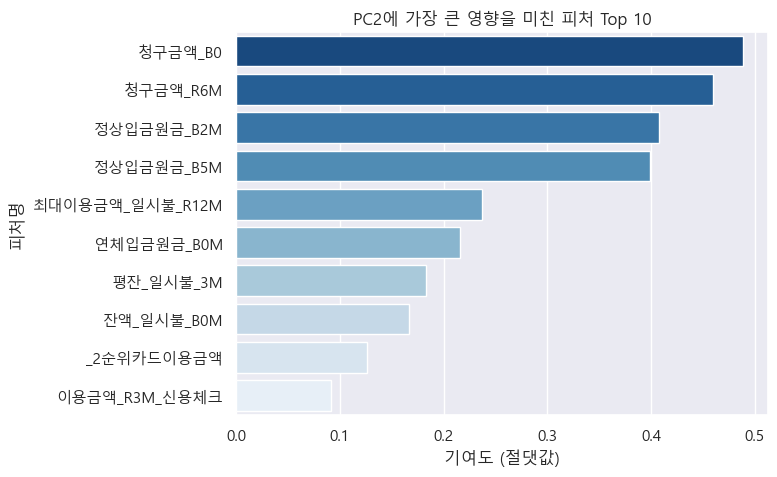

In [63]:
# 기여도 계산 (절댓값 기준 상위 10개 피처)
top_pc1 = components_df['PC1'].abs().sort_values(ascending=False).head(10)
top_pc2 = components_df['PC2'].abs().sort_values(ascending=False).head(10)

# PC1 시각화
plt.figure(figsize=(8, 5))
sns.barplot(x=top_pc1.values, y=top_pc1.index, palette='Reds_r')
plt.title("PC1에 가장 큰 영향을 미친 피처 Top 10")
plt.xlabel("기여도 (절댓값)")
plt.ylabel("피처명")
plt.tight_layout()
plt.show()

# PC2 시각화
plt.figure(figsize=(8, 5))
sns.barplot(x=top_pc2.values, y=top_pc2.index, palette='Blues_r')
plt.title("PC2에 가장 큰 영향을 미친 피처 Top 10")
plt.xlabel("기여도 (절댓값)")
plt.ylabel("피처명")
plt.tight_layout()
plt.show()

**[PC1에 영향을 많이 준 피처 Top 10]**

- 대부분 카드 사용 패턴(이용금액, 이용건수) 과 관련된 변수들이다.
- 특히 신용카드, 오프라인 소비, 업종별 이용금액은 A/B 클래스 간 행동 차이를 잘 설명할 수 있다.
- A/B 분류에서 소비 성향이 중요한 결정 요인임을 시사한다.

**[PC2에 영향을 많이 준 피처 Top 10]**

- `청구금액`, `입금/연체 정보` 등 **카드 대금 납부**와 관련된 변수들이 많다.
- A/B 클래스 간 금융건전성이나 상환 태도에서 차이가 있다는 것을 의미한다.
- A는 일정한 금액을 꾸준히 납부하지만, B는 적은 금액 또는 불규칙한 상환?

#### 2단계 kfold 교차검증

In [46]:
# 평가 지표 정의 
f1_macro = make_scorer(f1_score, average='macro')

# 교차검증 설정
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 모델 정의
model = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    tree_method='hist',
    device='cuda'
)

# 교차검증 실행 (X_not_e, y_not_e_encoded는 사전 정의된 데이터 사용)
cv_scores = cross_val_score(model, X_not_e, y_not_e_encoded, cv=cv, scoring=f1_macro)

In [47]:
# 결과 출력
print("[Fold별 f1_macro score]")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")
print(f"평균 f1_macro score: {cv_scores.mean():.4f}")

[Fold별 f1_macro score]
Fold 1: 0.4305
Fold 2: 0.5239
Fold 3: 0.4335
Fold 4: 0.4258
Fold 5: 0.4555
Fold 6: 0.4894
Fold 7: 0.4350
Fold 8: 0.5033
Fold 9: 0.4501
Fold 10: 0.4537
평균 f1_macro score: 0.4601


다음 단계에서 진행할 대략적인 흐름

- A/B 샘플만 추출
- 피처 분포 시각화 + 통계 비교 (sns.histplot, df.groupby().mean())
- 별도 A/B 분류 모델 만들어서 교차검증
- 클래스 분리 잘 되는지 확인 → 성능 낮으면 피처 엔지니어링 or 오버샘플링

### Threadhold 조정

#### 1. A/B 샘플 추출

In [48]:
# A/B만 추출
df_ab = df[df['Segment'].isin(['A', 'B'])].copy()

# 라벨 인코딩 (A → 0, B → 1)
le_ab = LabelEncoder()
df_ab['Segment_encoded'] = le_ab.fit_transform(df_ab['Segment'])

# X, y 분리
X_ab = df_ab.drop(columns=['Segment', 'Segment_encoded'])
y_ab = df_ab['Segment_encoded']

print("A/B 샘플 수:\n", df_ab['Segment'].value_counts())

A/B 샘플 수:
 Segment
A    972
B    144
Name: count, dtype: int64


#### 2. 데이터 스케일링

In [49]:
scaler = StandardScaler()
X_ab_scaled = scaler.fit_transform(X_ab)

#### 3. XGBoost 이진 분류 + 교차검증(10-Fold)

In [50]:
# f1-macro 기준으로 평가
f1_macro = make_scorer(f1_score, average='macro')

# StratifiedKFold 설정
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 모델 정의
model_ab_bin = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    tree_method="hist",
    device="cuda"
)

# 교차검증 수행
cv_scores_ab = cross_val_score(model_ab_bin, X_ab_scaled, y_ab, cv=cv, scoring=f1_macro)

# 출력
print("\n[10-Fold A/B f1_macro score]")
for i, score in enumerate(cv_scores_ab, 1):
    print(f"Fold {i}: {score:.4f}")
print(f"\n평균 f1_macro score: {cv_scores_ab.mean():.4f}")


[10-Fold A/B f1_macro score]
Fold 1: 0.8488
Fold 2: 0.7255
Fold 3: 0.7480
Fold 4: 0.8874
Fold 5: 0.7820
Fold 6: 0.8133
Fold 7: 0.7802
Fold 8: 0.8131
Fold 9: 0.8873
Fold 10: 0.6496

평균 f1_macro score: 0.7935


####  4. Confusion Matrix & Classification Report (10-Fold)

In [51]:
results = []  # 결과 저장용 리스트

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold = 1

for train_idx, val_idx in cv.split(X_ab_scaled, y_ab):
    X_tr, X_val = X_ab_scaled[train_idx], X_ab_scaled[val_idx]
    y_tr, y_val = y_ab.iloc[train_idx], y_ab.iloc[val_idx]

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        use_label_encoder=False,
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        random_state=fold,
        tree_method="hist",
        device="cuda"
    )
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    # 리포트 문자열 저장
    report = classification_report(y_val, y_pred, digits=4)
    cm = confusion_matrix(y_val, y_pred)

    results.append({
        "fold": fold,
        "confusion_matrix": cm,
        "classification_report": report
    })

    fold += 1


##### 각 Fold 별 결과 저장

In [52]:
with open("./result/AB_classification_reports.txt", "w", encoding="utf-8") as f:
    for res in results:
        f.write(f"\n[Fold {res['fold']}]\n")
        f.write("Confusion Matrix:\n")
        f.write(str(res["confusion_matrix"]) + "\n")
        f.write("Classification Report:\n")
        f.write(res["classification_report"] + "\n")

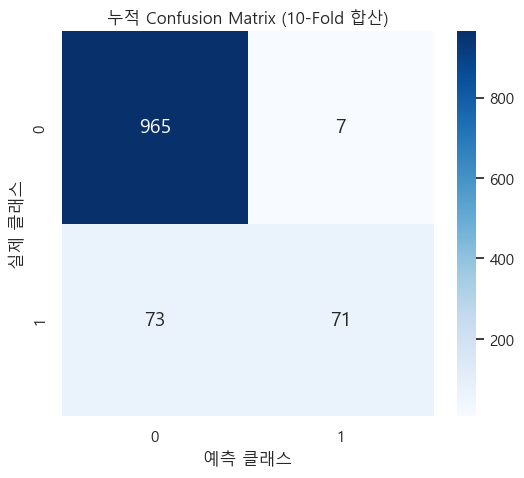

In [53]:
# confusion matrix만 추출해서 합산
sum_cm = np.sum([res['confusion_matrix'] for res in results], axis=0)

# 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(sum_cm, annot=True, fmt='d', cmap='Blues')
plt.title("누적 Confusion Matrix (10-Fold 합산)")
plt.xlabel("예측 클래스")
plt.ylabel("실제 클래스")
plt.show()

In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# 실제값과 예측값을 누적 confusion matrix로부터 복원
y_true = [0]*965 + [0]*7 + [1]*73 + [1]*71
y_pred = [0]*965 + [1]*7 + [0]*73 + [1]*71

# 계산
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")


Precision: 0.9103
Recall:    0.4931
F1-score:  0.6396
Accuracy:  0.9283


### 모델 저장해서 다시

In [56]:
import json

results = []  # 결과 저장 리스트

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold = 1

for train_idx, val_idx in cv.split(X_ab_scaled, y_ab):
    X_tr, X_val = X_ab_scaled[train_idx], X_ab_scaled[val_idx]
    y_tr, y_val = y_ab.iloc[train_idx], y_ab.iloc[val_idx]

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        use_label_encoder=False,
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        random_state=fold,
        tree_method="hist",
        device="cuda"
    )
    model.fit(X_tr, y_tr)

    # 예측 및 평가
    y_pred = model.predict(X_val)
    report = classification_report(y_val, y_pred, digits=4)
    cm = confusion_matrix(y_val, y_pred)

    # 모델 저장
    model.save_model(f"./model/model_ab_fold{fold}.json")

    # 결과 저장
    results.append({
        "fold": fold,
        "confusion_matrix": cm.tolist(),
        "classification_report": report
    })

    fold += 1

# 결과 JSON 저장 (옵션)
with open("./model/ab_fold_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4, ensure_ascii=False)

In [59]:
# 설정
threshold = 0.3
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold = 1

# 결과 저장용 리스트
all_conf_matrices = []
all_precisions = []
all_recalls = []
all_f1s = []

for train_idx, val_idx in cv.split(X_ab_scaled, y_ab):
    X_tr, X_val = X_ab_scaled[train_idx], X_ab_scaled[val_idx]
    y_tr, y_val = y_ab.iloc[train_idx], y_ab.iloc[val_idx]

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        use_label_encoder=False,
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        random_state=fold,
        tree_method="hist",
        device="cuda"
    )
    model.fit(X_tr, y_tr)

    # 확률 예측 → threshold 적용
    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    # 혼동 행렬 및 지표 저장
    cm = confusion_matrix(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    all_conf_matrices.append(cm)
    all_precisions.append(precision)
    all_recalls.append(recall)
    all_f1s.append(f1)

    print(f"\n[Fold {fold} - Threshold={threshold}]")
    print(cm)
    print(classification_report(y_val, y_pred, digits=4))
    
    fold += 1

# 평균 confusion matrix
avg_cm = np.mean(all_conf_matrices, axis=0).astype(int)

print("\n[10-Fold 평균 Confusion Matrix]")
print(avg_cm)

print(f"\n평균 Precision: {np.mean(all_precisions):.4f}")
print(f"평균 Recall:    {np.mean(all_recalls):.4f}")
print(f"평균 F1-score:  {np.mean(all_f1s):.4f}")


[Fold 1 - Threshold=0.3]
[[96  2]
 [ 3 11]]
              precision    recall  f1-score   support

           0     0.9697    0.9796    0.9746        98
           1     0.8462    0.7857    0.8148        14

    accuracy                         0.9554       112
   macro avg     0.9079    0.8827    0.8947       112
weighted avg     0.9543    0.9554    0.9546       112


[Fold 2 - Threshold=0.3]
[[97  1]
 [ 7  7]]
              precision    recall  f1-score   support

           0     0.9327    0.9898    0.9604        98
           1     0.8750    0.5000    0.6364        14

    accuracy                         0.9286       112
   macro avg     0.9038    0.7449    0.7984       112
weighted avg     0.9255    0.9286    0.9199       112


[Fold 3 - Threshold=0.3]
[[95  2]
 [ 7  8]]
              precision    recall  f1-score   support

           0     0.9314    0.9794    0.9548        97
           1     0.8000    0.5333    0.6400        15

    accuracy                         0.9196    

In [60]:
# 결과 txt로 저장
with open("./result/AB_classification_reports_threshold_03.txt", "w", encoding="utf-8") as f:
    for res in results:
        f.write(f"\n[Fold {res['fold']}]\n")
        f.write("Confusion Matrix:\n")
        f.write(str(res["confusion_matrix"]) + "\n")
        f.write("Classification Report:\n")
        f.write(res["classification_report"] + "\n")

- Precision (정밀도) 0.86
    - 예측한 것 중에 실제로 맞은 비율이 여전히 높다. 즉, 잘못된 긍정(False Positive)이 많지 않다.

- Recall (재현율) 0.64 → 이전보다 향상
    - 실제로 해당 클래스인 것들 중에서 얼마나 잘 찾아냈는가.
    - 모델이 A/B 중 적은 수의 샘플(특히 B)을 더 잘 잡아내고 있다는 신호.

- F1-score (0.73)
    - 전체적으로 모델 성능이 꽤 안정적으로 향상.